# ICC132 – Actividad Integradora: AES en Python
## El mensaje de Garfield

**Nombre:** Hiram Zuniga  
**Materia:** Administración y Seguridad de Redes  
**Profesora:** Dra. Vanessa Miranda  


Para empezar CIA = Confidencialidad, Integridad, Disponibilidad

Contexto: En DES se tienen 56 bits efectivos de llave. En esta actividad Garfield utilizará AES-128
en modo CBC. Sin embargo, la implementación contiene errores de seguridad.

### **Codigo a analizar**

In [1]:
# Primero instalamos crypto porque si no saldra un error jaja
%pip install pycryptodome -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
from Crypto.Cipher import AES
from Crypto.Util.Padding import pad, unpad
import base64

LLAVE = b"garfield123"
IV_FIJO = b"0000000000000000"
MENSAJE = "Nermal, el lunes traeme lasagna extra porque Jon no sabe cocinar"

def cifrar(mensaje, llave, iv):
    cipher = AES.new(llave, AES.MODE_CBC, iv)
    ct = cipher.encrypt(pad(mensaje.encode(), AES.block_size))
    return base64.b64encode(ct).decode()

def descifrar(cifrado, llave, iv):
    cipher = AES.new(llave, AES.MODE_CBC, iv)
    pt = unpad(cipher.decrypt(base64.b64decode(cifrado)), AES.block_size)
    return pt.decode()

msg1 = cifrar(MENSAJE, LLAVE, IV_FIJO)
msg2 = cifrar("Odie es un perro tonto", LLAVE, IV_FIJO)
msg3 = cifrar("La clave es: lasagna2024", LLAVE, IV_FIJO)

print("Mensaje 1:", msg1)
print("Mensaje 2:", msg2)
print("Mensaje 3:", msg3)
print("\nDescifrado:", descifrar(msg1, LLAVE, IV_FIJO))

El codigo naturalmente va a fallar y es lo que tenemos que identificar

## Pregunta 1. Tres errores de seguridad

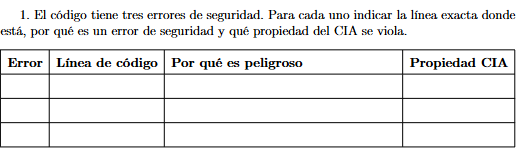

Okay para responder estas preguntas vamonos de error 1 al 3, 
# Error 1
El error 1 ocurre en donde se define la llave, LLAVE = b"garfield123" , **porque esta mal?** La llave esta directamente en el codigo y eso es PESIMO, literalmente llaves, tokens y cualquier cosa sensible no puede estar explicitamente en el codigo porque se pueden lekear, se deveria de usar una env variable o algo parecido, tampoco tiene un tamano valido para el codigo de AES que estamos utilizando. El riesgo y peligro que conlleva es que si alguien ve el codigo source del feature, o se mete a github o algo pueden mirar la llave y entonces se esta poniendo en riesgo la propiedad de **confidencialidad** porque si alguien mira la llave ya no es confidencial, nisiquiera tiene que ser alguien ajeno a la empresa, en la misma empresa pueden pasar errores 
# Error 2
El error 2 ocurre en donde se define el IV_FIJO = b"0000000000000000", **porque?** bueno basicamente no se puede reutilizar, tendria que ser aleatorio y diferente para cada cifrado, tendriamos que usar un generador de numeros aleatorios o algo parecido, no tenerlo definido en el codigo de manera explicita jaja. El peligro es que si se reutiliza el mismo, se pueden filtrar patrones o puedes incluso llegar a la llave porque no es aleatorio es deterministico el IV. Se afecta la **confidencialidad** tambien de la CIA, ya que es algo sensible que no tiene que estar definido en el codigo.
# Error 3 
El error 3 ocurre a la hora de llamar las funciones de cifrado y descifrar, **porque** el IV se deberia de manejar por separado, es parecido al error 2 y hace la implementacion mas pobre. El peligro es que si se llega a usar el IV incorrecto el descifrado falla o hace algo incorrecto, con este se puede afectar la **Disponibilidad e incluso integridad**, Disponibilidad porque puede que nisiquiera podamos descifrar el mensaje y no estara disponible e Integridad porque si algo llega a pasar mal por el IV incorrecto en el descifrado ni nos vamos a dar cuenta y puede pasar la casualidad que nos de otro texto jajaj 

## Pregunta 2. ¿Por qué AES rechaza la llave?
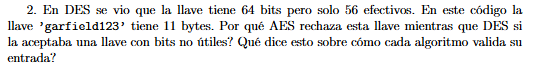

bueno esto es porque AES solo acepta las llaves de Longitud **EXACTA**, entonces la cadena que definimos de garfield123 tiene 11 bytes, esto no coincide con nada que AES acepta ya sea 16,24 o 32. Por eso el AES lo rechaza directamente. Esto infiere que AES valida de manera estricta la longitud de la llave que se le pasa

## Pregunta 3. Opciones para corregir la llave
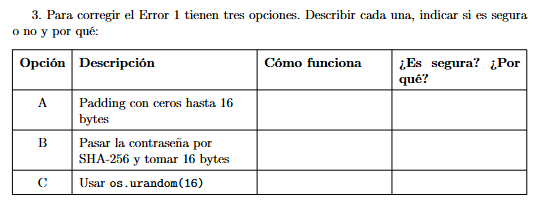

### Opcion A: 
esta opcion dice que usemos padding con ceros hasta llegar a los 16 bytes que es lo aceptable para el AES. **Como funciona?** Simplemente se agregan bytes 0 hasta completar los 16, **es seguro?** NO, **Porque?** porque sigue siendo la misma contrasena debil que teniamos antes jaja pero solo la rellenamos con 0s y eso no la hace mas dificil

### Opcion B:
Esta opcion nos dice que pasemos la contrasena por SHA-256 y solo tomemos 16 bytes, **Como funciona?** se calcula el hash SHA-256 de la contrasena garfield123 y solo usamos 16 bytes de todo el resultado, **es segura?** No, es mejor que la A, pero todavia no es aceptable, **porque?** pues porque seguimos partiendo de la contrasena debil que teniamos, que si se hasheo? pues si, es mejor, pero como yo pase la contrasena por SHA-256 el hacker puede hacer lo mismo, entonces en esencia SIGUE SIENDO LA MISMA CONTRASENA DEBIL, el haber cortado a 16 bytes fue mejor porque el hacker igual y no se le ocurre, pero sigue siendo la misma contrasena debil

### Opcion C:
Esta opcion dice usar os.random(16), **como funciona?** utilizamos la funcion os.urandom(16) que genera 16 bytes aleatorios criptograficamente seguros, **es seguro?** SI, por fin jaja, **porque?** porque este si es una llave aleatoria que es adecuada para el AES por su tamano de bytes y a parte no es debil como garfield123, y si nos damos cuenta, esta opcion es la unica segura y fue la unica que genero la llave de manera aleatoria, las otras solo estaban tratando de disfrazar la llave de garfield123

## Pregunta 4. CSPRNG y os.urandom()
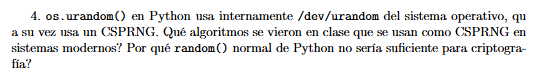

**R =** Actualmente no se me viene a la mente de los algoritmos que vimos en clase, pero urandom es mejor que random() normal porque os.urandom() obtiene los bytes aleatorios del sistema operativo, usando el generador criptograficamente seguro del que se habla en la pregunta (CSPRING), mientras que el random() normal de python se queda atras porque es de simulacion, proposito general y al final del dia es una funcion en python entonces puede ser predecible o si el hacker sabe como funciona la funcion puede simularla el mismo y llegar a la llave o algo parecido

### **Correcion del codigo**

In [ ]:
from Crypto.Cipher import AES
from Crypto.Util.Padding import pad, unpad
import base64
import os

LLAVE = os.urandom(16) # Ahora usamos el os.urandom para la llave, tampoco usamos random() de python porque no es suficiente
MENSAJE = "Nermal, el lunes traeme lasagna extra porque Jon no sabe cocinar"

def cifrar(mensaje, llave):
    iv = os.urandom(16) # Usar os.urandom tambien para el IV
    cipher = AES.new(llave, AES.MODE_CBC, iv)
    ct = cipher.encrypt(pad(mensaje.encode(), AES.block_size))
    cifrado = iv + ct # primero el IV, luego el cyphertext
    print("Bytes mensaje original:", len(mensaje.encode())) # mostrar el tamano en bytes del mensaje original
    print("Bytes cifrado en base64:", len(base64.b64encode(cifrado))) # y el del cifrado en base64
    return base64.b64encode(cifrado).decode()

def descifrar(cifrado, llave): # ya no se le pasa IV por separado, va dentro de cifrado y va primero el IV
    datos = base64.b64decode(cifrado)
    iv = datos[:16]
    ct = datos[16:]
    cipher = AES.new(llave, AES.MODE_CBC, iv)
    pt = unpad(cipher.decrypt(ct), AES.block_size)
    return pt.decode()

# 
msg1 = cifrar(MENSAJE, LLAVE)
msg2 = cifrar("Odie es un perro tonto", LLAVE)
msg3 = cifrar("La clave es: lasagna2024", LLAVE)

print("Mensaje 1:", msg1)
print("Mensaje 2:", msg2)

print("Mensaje 3:", msg3)

print("\nDescifrado:", descifrar(msg1, LLAVE))

Bytes mensaje original: 64
Bytes cifrado en base64: 128
Bytes mensaje original: 22
Bytes cifrado en base64: 64
Bytes mensaje original: 24
Bytes cifrado en base64: 64
Mensaje 1: Keg3OQyT7GN75pM7Ym3wbfaj1szsAEzuMP9vCrVBgHjyPWv2c/QlwbTKbIDIpb0dR4yQ/enN9pYY4cdu2dSTjMSgswfZva5qGLihdM5iDM6Avg7qPCEB5OKwTFPCmHd9
Mensaje 2: erVDLtf4GbR3j0XTjcoN+1xkxOGOBP1LkWjygJDT18KHNIh69X0QZ/GLqPgGy62X
Mensaje 3: FhoxRQ/jAW5neJ4kHONJMKtiU6KGpB0UkoGJgJCxMBQbXKjqcJP+KqUnHNuknUwp

Descifrado: Nermal, el lunes traeme lasagna extra porque Jon no sabe cocinar


## Pregunta 6. ¿Qué pasa si Garfield hubiera usado CTR?

CTR es un modo de operacion de AES, se llama counter mode, lo que hace es reutilizr el mismo nonce con la misma llave y es todavia mas grave que reutilizar el IV en CBC jaja. Porque reutilizar el mismo IV filtra patrones verdad, pero en CTR reutilizar el mismo nonce con la misma llave significa reutilizar el mismo flujo de clave, y un atacante se las puede ingeniar y maybe usar un XOR entre 2 ciphertexts y obtener el XOR directo de los mensajes originales con lo que ya se puede hacer un ataque directo por lo que si es mas grave

## Conclusión

Esta actividad realmente me ayudo, porque aunque pongo atencion en clase, estos notebooks en practica me ayudan a aterrizar mas la teoria, me acorde de lo que vimos en clase, me asocie con los bytes. El algoritmo AES, porque algunas practicas estan mal en las llaves, porque os.urandom es lo correcto en criptografia, etc. me gusto mucho la actividad
